In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 127MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 36.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 95.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.83MB/s]


In [3]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 400)

        self.fc_mu = nn.Linear(400, 2)
        self.fc_logvar = nn.Linear(400, 2)

        self.fc2 = nn.Linear(2, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

In [5]:
def loss_function(recon_x, x, mu, logvar):

    BCE = F.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    )

    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD

In [7]:
model = VAE()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(-1, 784)

        optimizer.zero_grad()

        recon, mu, logvar = model(images)

        loss = loss_function(
            recon,
            images,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}, Loss = {total_loss:.2f}"
    )

Epoch 1, Loss = 11427623.06
Epoch 2, Loss = 9988577.10
Epoch 3, Loss = 9713120.44
Epoch 4, Loss = 9579632.22
Epoch 5, Loss = 9489509.31


In [8]:
import matplotlib.pyplot as plt

model.eval()

z_points = []
labels = []

with torch.no_grad():

    for images, target in train_loader:

        images = images.view(-1,784)

        mu, _ = model.encode(images)

        z_points.append(mu)
        labels.append(target)

z_points = torch.cat(z_points)
labels = torch.cat(labels)

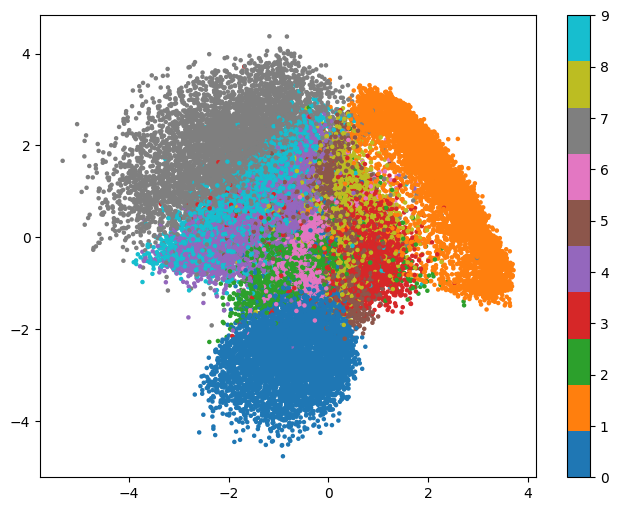

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    z_points[:,0],
    z_points[:,1],
    c=labels,
    cmap='tab10',
    s=5
)

plt.colorbar()
plt.show()

In [10]:
z = torch.randn(16,2)

with torch.no_grad():
    samples = model.decode(z)

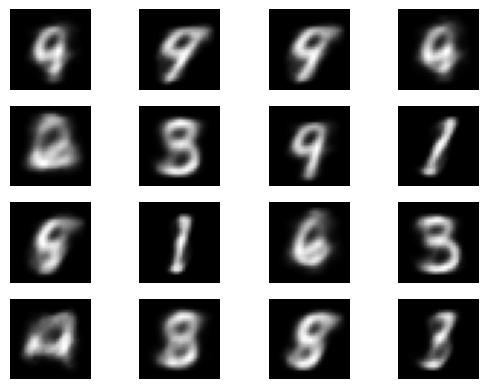

In [11]:
fig, axes = plt.subplots(4,4)

for i, ax in enumerate(axes.flat):

    img = samples[i].view(28,28)

    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.show()

In [12]:
img1,_ = train_dataset[0]
img2,_ = train_dataset[1]

In [13]:
with torch.no_grad():

    mu1,_ = model.encode(
        img1.view(1,784)
    )

    mu2,_ = model.encode(
        img2.view(1,784)
    )

In [14]:
alphas = torch.linspace(0,1,10)

interpolations = []

for alpha in alphas:

    z = (1-alpha)*mu1 + alpha*mu2

    sample = model.decode(z)

    interpolations.append(
        sample.view(28,28)
    )

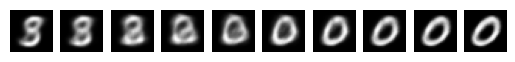

In [16]:
fig, axes = plt.subplots(1,10)

for i in range(10):

    axes[i].imshow(
        interpolations[i].detach().numpy(),
        cmap='gray'
    )

    axes[i].axis('off')

plt.show()